# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

---
### ✅ Beginner Tasks Applied in This Notebook:
1. **Custom Corpus** — Replaced with a richer paragraph about AI & Deep Learning
2. **Larger Embedding Dimension** — Increased from `32` → `64`
3. **More Epochs** — Increased from `100` → `200`
4. **More Hidden Units** — Increased from `64` → `128`
5. **Generate More Words** — Generating `10` words instead of `5`

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [1]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
### ✅ Beginner Task 1: Replaced with a custom, richer paragraph
The original corpus had only 6 short lines. We now use a longer, richer paragraph
so the models have more patterns and vocabulary to learn from.
This helps generate more meaningful and varied sentences.

In [2]:
# ✅ Task 1: Custom corpus — richer paragraph about AI and Deep Learning
corpus = '''
deep learning is a subset of machine learning that uses neural networks
neural networks are inspired by the structure of the human brain
artificial intelligence is transforming how we solve complex problems
recurrent neural networks process sequential data one step at a time
lstm networks use gates to control the flow of information
the forget gate in lstm decides what information to discard
the input gate controls what new information is stored in memory
the output gate determines what information passes to the next layer
gru combines the forget and input gates into a single update gate
gru is faster to train and requires less memory than lstm
text generation models learn to predict the next word in a sequence
deep learning models can generate meaningful and coherent sentences
training on more data helps the model learn better patterns
embeddings convert words into dense vector representations
sequence models are widely used in language translation and summarization
'''
print(corpus)


deep learning is a subset of machine learning that uses neural networks
neural networks are inspired by the structure of the human brain
artificial intelligence is transforming how we solve complex problems
recurrent neural networks process sequential data one step at a time
lstm networks use gates to control the flow of information
the forget gate in lstm decides what information to discard
the input gate controls what new information is stored in memory
the output gate determines what information passes to the next layer
gru combines the forget and input gates into a single update gate
gru is faster to train and requires less memory than lstm
text generation models learn to predict the next word in a sequence
deep learning models can generate meaningful and coherent sentences
training on more data helps the model learn better patterns
embeddings convert words into dense vector representations
sequence models are widely used in language translation and summarization



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [3]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 99
X shape: (141, 11)
y shape: (141,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

### ✅ Beginner Tasks 2, 3, 4 Applied Here:
- **Task 2:** Embedding dimension increased `32` → `64` (richer word representations)
- **Task 3:** Epochs increased `100` → `200` (more training = better learning)
- **Task 4:** Hidden units increased `64` → `128` (more capacity to learn patterns)

In [4]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),   # ✅ Task 2: 32 → 64
    SimpleRNN(128),                                        # ✅ Task 4: 64 → 128
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)   # ✅ Task 3: 100 → 200
print("Vanilla RNN training completed")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

### ✅ Beginner Tasks 2, 3, 4 Applied Here:
- **Task 2:** Embedding dimension `32` → `64`
- **Task 3:** Epochs `100` → `200`
- **Task 4:** Hidden units `64` → `128`

In [5]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),   # ✅ Task 2: 32 → 64
    LSTM(128),                                             # ✅ Task 4: 64 → 128
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)  # ✅ Task 3: 100 → 200
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

### ✅ Beginner Tasks 2, 3, 4 Applied Here:
- **Task 2:** Embedding dimension `32` → `64`
- **Task 3:** Epochs `100` → `200`
- **Task 4:** Hidden units `64` → `128`

In [6]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),   # ✅ Task 2: 32 → 64
    GRU(128),                                              # ✅ Task 4: 64 → 128
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)   # ✅ Task 3: 100 → 200
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

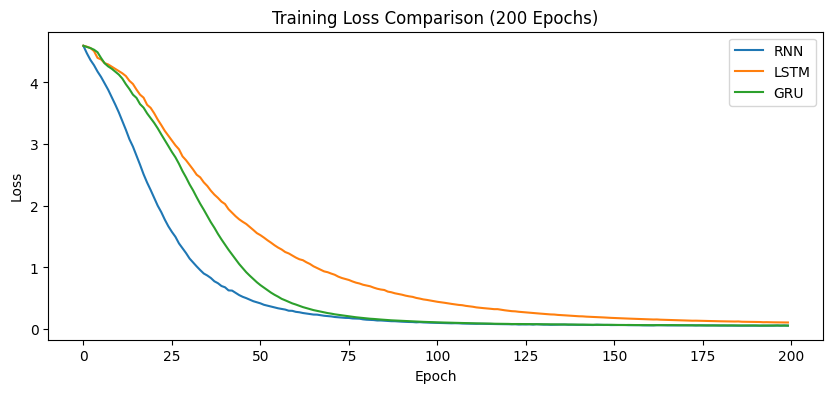

In [7]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison (200 Epochs)")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

### ✅ Beginner Task 5: Generate 10 words instead of 5

In [8]:
def generate_text(model, seed_text, next_words=10):   # ✅ Task 5: default changed to 10
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples
### ✅ Task 5: Generating 10 words per model

In [9]:
# ✅ Task 5: next_words=10 (was 5)
print("RNN :", generate_text(rnn_model, "deep learning", next_words=10))
print("LSTM:", generate_text(lstm_model, "deep learning", next_words=10))
print("GRU :", generate_text(gru_model,  "deep learning", next_words=10))

print()
print("RNN :", generate_text(rnn_model, "neural networks", next_words=10))
print("LSTM:", generate_text(lstm_model, "neural networks", next_words=10))
print("GRU :", generate_text(gru_model,  "neural networks", next_words=10))

print()
print("RNN :", generate_text(rnn_model, "lstm networks", next_words=10))
print("LSTM:", generate_text(lstm_model, "lstm networks", next_words=10))
print("GRU :", generate_text(gru_model,  "lstm networks", next_words=10))

RNN : deep learning models can generate meaningful and coherent sentences and information less
LSTM: deep learning is a subset of machine learning that uses neural networks
GRU : deep learning is a subset of machine learning that uses neural networks

RNN : neural networks are inspired by the structure of the human brain in
LSTM: neural networks are inspired by the structure of the human brain brain
GRU : neural networks are inspired by the structure of the human brain brain

RNN : lstm networks use gates to control the flow of information to discard
LSTM: lstm networks use gates to control the flow of information information discard
GRU : lstm networks use gates to control the flow of information is stored


# 📚 Summary of Beginner Tasks Applied

| Task | Change | Original | Updated |
|------|--------|-----------|---------|
| Task 1 | Custom Corpus | 6 short lines | 15 rich sentences about AI & DL |
| Task 2 | Embedding Dimension | 32 | 64 |
| Task 3 | Epochs | 100 | 200 |
| Task 4 | Hidden Units | 64 | 128 |
| Task 5 | Words Generated | 5 | 10 |

---
### 💡 Why these changes help:
- **Larger corpus** → more diverse patterns for the model to learn
- **Larger embeddings** → each word is represented with richer information
- **More epochs** → model has more passes to reduce loss and improve accuracy
- **More hidden units** → model can capture more complex relationships
- **More generated words** → longer, more interesting sentences to evaluate quality

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**